# Practice With out Transformers

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv('../datasets/employee_promotion.csv')
df.sample(3)

,Employee_ID,Age,Experience,Monthly_Salary,Bonus,Gender,Department,City,Education,Performance,Work_Mode,Promotion
23,EMP024,42.0,18.0,300000.0,70000,Female,Management,Islamabad,PhD,Excellent,Office,Yes
0,EMP001,25.0,2.0,28000.0,5000,Male,IT,Lahore,Bachelor,Good,Remote,No
24,EMP025,30.0,6.0,56000.0,9200,Male,Finance,Lahore,Master,Good,Hybrid,Yes


In [3]:
# df.isnull().sum()
df.drop(columns=['Employee_ID'],inplace=True)
print(df.isnull().sum())

Age               2
Experience        2
Monthly_Salary    1
Bonus             0
Gender            0
Department        0
City              0
Education         0
Performance       0
Work_Mode         0
Promotion         0
dtype: int64


In [4]:
X=df.drop(columns=['Promotion'])
Y=df['Promotion']
# print(Y)


In [5]:
from sklearn.model_selection import  train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
print(X_train,Y_train)
print(X_test,Y_test)

     Age  Experience  Monthly_Salary  Bonus  Gender  Department       City  \
25  27.0         3.0         34000.0   5800  Female   Marketing    Karachi   
26  39.0        14.0        165000.0  33000    Male  Management  Islamabad   
15  31.0         6.0         52000.0   8500  Female       Sales     Lahore   
28  35.0        10.0         88000.0  17000    Male     Finance    Karachi   
3    NaN        10.0         95000.0  18000  Female          IT     Lahore   
24  30.0         6.0         56000.0   9200    Male     Finance     Lahore   
1   32.0         8.0         65000.0  12000  Female          HR    Karachi   
12  45.0        20.0        450000.0  95000    Male  Management     Lahore   
6   35.0         9.0         78000.0  14000    Male     Finance     Lahore   
8   24.0         1.0         25000.0   4000    Male       Sales  Islamabad   
0   25.0         2.0         28000.0   5000    Male          IT     Lahore   
22  28.0         4.0         39000.0   7200    Male       Sales 

In [6]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression

In [7]:
num_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scalar',StandardScaler())
])



In [8]:
nom_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('one',OneHotEncoder(handle_unknown='ignore'))
])

In [9]:
ord_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ord',OrdinalEncoder(categories=[['Bachelor', 'Master', 'PhD'],
        ['Average', 'Good', 'Excellent']]))
])

In [10]:
num_col=["Age","Experience","Monthly_Salary","Bonus"]
nom_col=['Gender','Department','Work_Mode','City']
ord_col=['Education','Performance']

In [11]:
preprocess=ColumnTransformer([
    ('numeric_processing',num_pip,num_col),
    ('nominal_processing',nom_pip,nom_col),
    ('ordinal_processing',ord_pip,ord_col)
])

In [12]:
model=Pipeline([
    ('prprocessing',preprocess),
    ('model',LogisticRegression())
])

In [13]:
model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Age','Experience','Monthly_Salary',...,'Education','Performance', 'Work_Mode']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_processing', ...), ('nominal_processing', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop

In [14]:
y_pred=model.predict(X_test)
print(y_pred)

['No' 'Yes' 'No' 'Yes' 'Yes' 'No']


In [15]:
from sklearn.metrics import accuracy_score
accuray=accuracy_score(Y_test,y_pred)*100
print(accuray)

100.0


In [16]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         3
         Yes       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [17]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_test, y_pred))

[[3 0]
 [0 3]]


In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, Y, cv=5)

print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
1.0


# Transformer Concept With Pipeline In New Data Set

In [19]:
df=pd.read_csv('../datasets/health_insurance.csv')
df.sample(3)

,Customer_ID,Age,BMI,Annual_Income,Medical_Bill,Gender,Smoking_Status,City,Education,Health_Score,Insurance
5,C006,34.0,25.4,65000.0,6000.0,Female,No,Islamabad,Master,Good,Yes
10,C011,58.0,33.6,500000.0,80000.0,Male,Yes,Karachi,PhD,Excellent,Yes
15,C016,31.0,24.3,NaN,4200.0,Female,No,Lahore,Bachelor,Average,No


In [20]:
df.isnull().sum()

Customer_ID       0
Age               1
BMI               1
Annual_Income     1
Medical_Bill      1
Gender            0
Smoking_Status    0
City              0
Education         0
Health_Score      0
Insurance         0
dtype: int64

In [21]:
df.drop(columns=['Customer_ID'],inplace=True)

In [22]:
X1=df.drop(columns=['Insurance'])
# print(X)
Y1=df['Insurance']

In [23]:
from sklearn.model_selection import train_test_split
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X1,Y1,test_size=0.2,random_state=42)

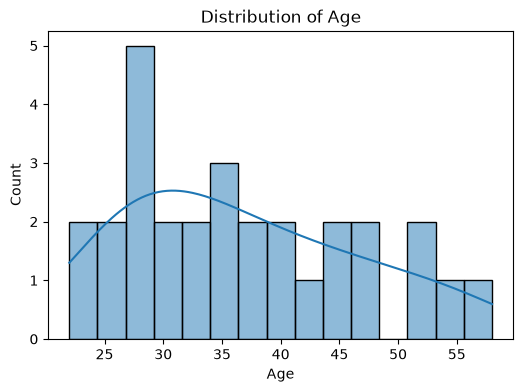

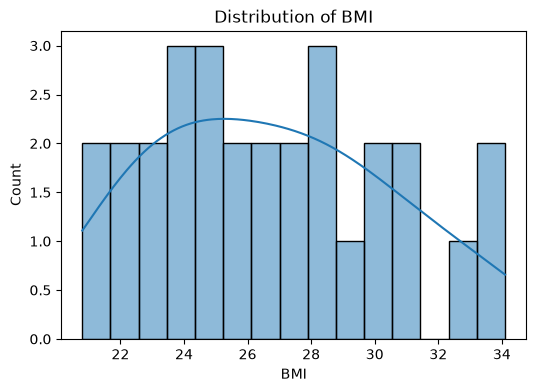

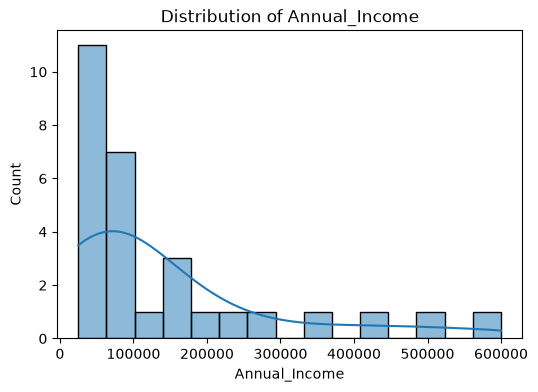

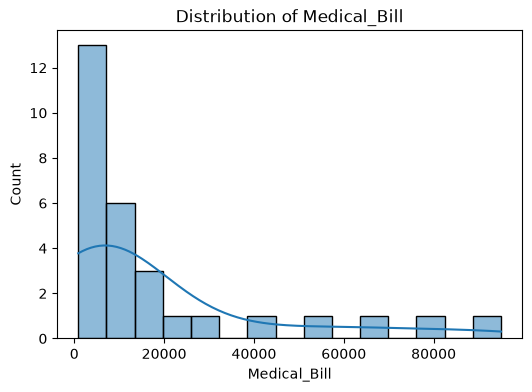

In [24]:
num_cols = ['Age', 'BMI', 'Annual_Income', 'Medical_Bill']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=15)
    plt.title(f"Distribution of {col}")
    plt.show()

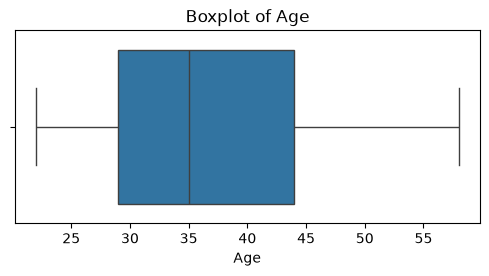

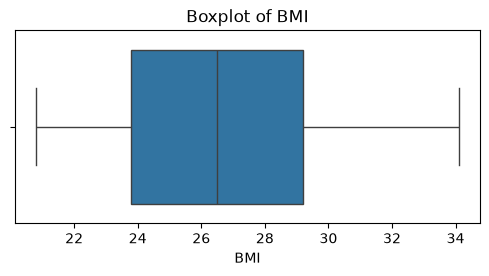

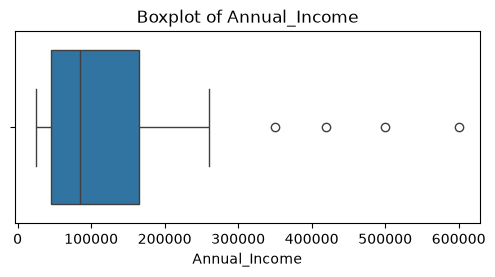

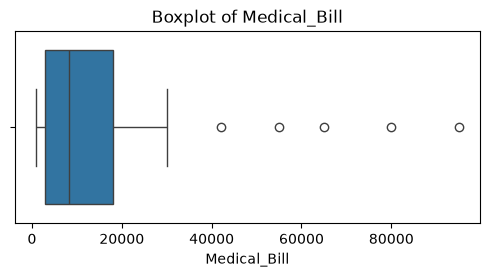

In [25]:
for col in num_cols:
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

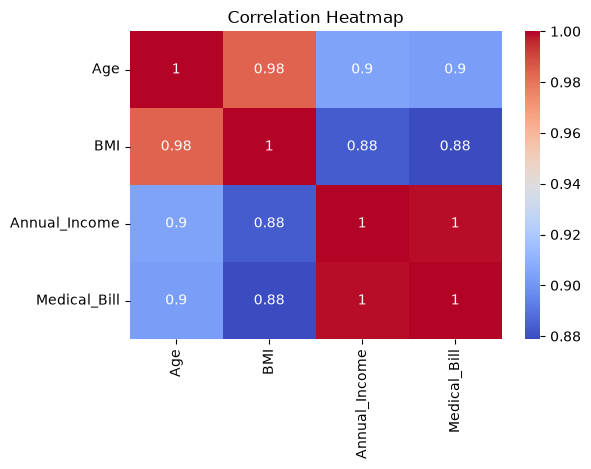

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df[['Age','BMI','Annual_Income','Medical_Bill']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [28]:
norm_num_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaling',StandardScaler())
])

In [29]:
from sklearn.preprocessing import FunctionTransformer
skewed_num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('transformer',FunctionTransformer(np.log1p)),
    ('scalaing',StandardScaler())
])

In [30]:
nominal_pip = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [31]:

ord_pip=Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
('ord',OrdinalEncoder(categories=[ ['Bachelor', 'Master', 'PhD'],
    ['Average', 'Good', 'Excellent']]))
])

In [32]:
# Normal Numerical Columns
normal_num_cols = ['Age', 'BMI']

# Right Skewed Numerical Columns
skewed_num_cols = ['Annual_Income', 'Medical_Bill']

# Nominal (OneHotEncoder)
nominal_cols = ['Gender', 'Smoking_Status', 'City']

# Ordinal (OrdinalEncoder)
ordinal_cols = ['Education', 'Health_Score']

In [33]:
preprocessing=ColumnTransformer([
    ('nor_num_pip',norm_num_pip,normal_num_cols),
    ('skew_num_pip',skewed_num_pipeline,skewed_num_cols),
    ('nom_pip',nominal_pip,nominal_cols),
    ('ord_pip',ord_pip,ordinal_cols)
    
])

In [34]:
model=Pipeline([
    ('preprocess',preprocessing),
    ('model',LogisticRegression())
])

In [35]:
model.fit(X_Train,Y_Train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','BMI','Annual_Income',...,'City','Education','Health_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nor_num_pip', ...), ('skew_num_pip', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [36]:
y_prediction = model.predict(X_Test)

In [37]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_Test)

accuracy = accuracy_score(Y_Test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


In [38]:
from sklearn.metrics import classification_report

print(classification_report(Y_Test, y_pred))

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         4
         Yes       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_Test, y_pred)

print(cm)

[[4 0]
 [0 2]]


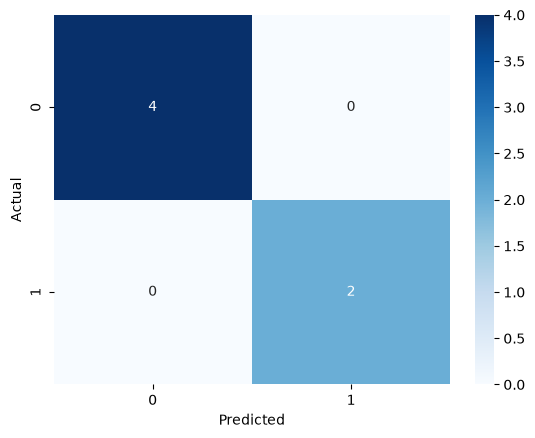

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X1,
    Y1,
    cv=5
)

print(scores)
print("Average Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Average Accuracy: 1.0


In [ ]:
import pickle

pickle.dump(model, open('../models/health_insurance_model.pkl', 'wb'))

In [ ]:
# import model and check 
loaded_model = pickle.load(
    open('../models/health_insurance_model.pkl', 'rb')
)

prediction = loaded_model.predict(X_Test)

print(prediction[:5])

['Yes' 'No' 'No' 'No' 'Yes']
